# 1 SETUP & IMPORTS

In [1]:
# Standard library and third-party imports
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Generator module imports
from src.pollution_generator.config import SimConfig
from src.pollution_generator.io_handler import generate_dataset_h5

# Predictor module imports
from src.pollution_predictor.config.configs import AppConfig
from src.pollution_predictor.data.transforms import PollutionTransforms
from src.pollution_predictor.data.dataset import PollutionStreamingDataset
from src.pollution_predictor.models import model_registry
from src.pollution_predictor.models.losses import OmniStructuralLoss
from src.pollution_predictor.engine.trainer import Trainer
from src.pollution_predictor.tracking.checkpointing import CheckpointManager
from src.pollution_predictor.tracking.logger import TrainingLogger
from src.pollution_predictor.inference.predictor import InferencePredictor
from src.pollution_predictor.evaluation.evaluator import SystemEvaluator
from src.pollution_predictor.evaluation.visualizer import plot_uncertainty

# Directory initialization logic
os.makedirs("data", exist_ok=True)
os.makedirs("logs", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("evaluation_results", exist_ok=True)

# System status reporting
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {'CUDA (GPU)' if torch.cuda.is_available() else 'CPU'}")

PyTorch Version: 2.10.0+rocm7.1
Device: CUDA (GPU)


# 2 DATASET GENERATION

In [2]:
MASTER_DATASET_PATH = "data/universal_master_train.h5"

# Configuration for maximum generalization (encompassing various environmental conditions)
universal_config = SimConfig(
    grid_x=64, grid_y=64, cell_size_m=100.0,
    sampling_steps=24, burn_in_steps=24,
    
    # Wide range of weather conditions
    wind_speed_range=(0.0, 8.0),     # From calm to storm
    wind_angle_range=(0.0, 6.28),    # Full 360-degree coverage
    wind_variability=0.2,            # High turbulence levels
    
    # Diverse city pollution baselines
    bg_pollution_base=4.0,           
    bg_fluctuation_amp=3.0,          
    bg_noise_std=1.0,
    
    # Infrastructure density variations
    num_static_sources=15,           # Up to 15 factories per city
    static_intensity_range=(50, 250),
    num_mobile_sources=120,          # High traffic density
    
    # Universal city simulation (Sensor topology)
    num_sensors=128,                 # Maximum physical sensor capacity
    num_layouts=4,                   # Number of distinct city configurations/maps
    packet_loss_prob=0.4             # 40% dynamic sensor dropout (simulates 50-100 active sensors per step)
)

# Dataset generation or verification logic
if not os.path.exists(MASTER_DATASET_PATH):
    print("Generating Universal Master Dataset (This may take some time)...")
    # Generate 1500 unique training scenarios
    generate_dataset_h5(universal_config, num_scenarios=2500, filename=MASTER_DATASET_PATH)
else:
    file_size_mb = os.path.getsize(MASTER_DATASET_PATH) / 1e6
    print(f"Universal dataset {MASTER_DATASET_PATH} already exists. Size: {file_size_mb:.1f} MB")

Generating Universal Master Dataset (This may take some time)...


Generating universal_master_train.h5: 100%|█| 2500/2500 [01:28<00:00, 28.20it/s]

Dataset saved to data/universal_master_train.h5. Size: 2044.45 MB


# 3 MODEL TRAINING

In [3]:
import os
import torch
import h5py
import json
from torch.utils.data import DataLoader

# Internal framework imports
from src.pollution_predictor.config.configs import AppConfig
from src.pollution_predictor.data.dataset import PollutionStreamingDataset
from src.pollution_predictor.data.transforms import PollutionTransforms
from src.pollution_predictor.models import model_registry
from src.pollution_predictor.models.losses import OmniStructuralLoss
from src.pollution_predictor.engine.trainer import Trainer
from src.pollution_predictor.tracking.checkpointing import CheckpointManager
from src.pollution_predictor.tracking.logger import TrainingLogger

# Device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"

# Directory cleanup for corrupted/stale models
ckpt_dir_path = "checkpoints/V2_Enhanced"
os.system(f"rm -rf {ckpt_dir_path}/*")
os.makedirs(ckpt_dir_path, exist_ok=True)

# Function to synchronize model architecture with dataset dimensions
def sync_config_with_dataset(config_dict, h5_path):
    with h5py.File(h5_path, 'r') as f:
        first_scen = list(f.keys())[0]
        readings_shape = f[first_scen]['sensor_readings'].shape
        config_dict["model"]["time_steps"] = readings_shape[1]
        
        meta = json.loads(f[first_scen].attrs.get('config', '{}'))
        config_dict["data"]["grid_size"] = [meta.get('grid_x', 64), meta.get('grid_y', 64)]
    return config_dict

# Training hyperparameters and configuration dictionary
config_dict_universal = {
    "data": {
        "dataset_dir": "data", "grid_size": [64, 64], "batch_size": 24,
        "use_wind": True, "use_augmentations": True, 
        "val_split": 0.15, "test_split": 0.05, "random_seed": 42
    },
    "model": {
        "architecture": "st_unet", "time_steps": 24, "use_wind": True,
        "params": {"hidden_dim": 64, "dropout_rate": 0.1} # Reduced dropout for smoothness
    },
    "train": {
        "epochs": 50, "learning_rate": 5e-4, "device": device, 
        "early_stopping_patience": 8, "accumulation_steps": 1,      
        "loss_warmup_epochs": 0, "freeze_encoder": False, "transfer_learning": False,   
        "resume_from": None
    },
    "tracker": {"log_dir": "logs", "checkpoint_dir": ckpt_dir_path, "experiment_name": "ResUNet_Bulletproof"}
}

# Apply synchronization logic
config_dict_universal = sync_config_with_dataset(config_dict_universal, MASTER_DATASET_PATH)
cfg_univ = AppConfig(**config_dict_universal)

# Data transformations and normalization setup
transforms_univ = PollutionTransforms(noise_floor=0.05) # Stricter sensor noise cutoff
transforms_univ.fit_from_h5(MASTER_DATASET_PATH)

# Dataset and DataLoader instantiation
train_ds = PollutionStreamingDataset(cfg_univ.data, MASTER_DATASET_PATH, transforms_univ, mode='train')
val_ds = PollutionStreamingDataset(cfg_univ.data, MASTER_DATASET_PATH, transforms_univ, mode='val')

train_loader = DataLoader(train_ds, batch_size=cfg_univ.data.batch_size)
val_loader = DataLoader(val_ds, batch_size=cfg_univ.data.batch_size)

# Neural network architecture initialization
univ_model = model_registry.create(
    name=cfg_univ.model.architecture, 
    time_steps=cfg_univ.model.time_steps,
    grid_x=cfg_univ.data.grid_size[0], grid_y=cfg_univ.data.grid_size[1],
    use_wind=cfg_univ.model.use_wind, **cfg_univ.model.params
)

# Optimization and Loss function setup
optimizer = torch.optim.AdamW(univ_model.parameters(), lr=cfg_univ.train.learning_rate, weight_decay=1e-4)

# Stable weighted loss function (Background vs Peaks)
criterion = OmniStructuralLoss(w_bg=10.0, w_peak=10.0)

# Tracking and Training Engine initialization
ckpt_mgr = CheckpointManager(cfg_univ.tracker.checkpoint_dir)
logger = TrainingLogger(
    log_dir=cfg_univ.tracker.log_dir, 
    experiment_name=cfg_univ.tracker.experiment_name, 
    config_to_log=cfg_univ.model_dump()
)
trainer = Trainer(univ_model, optimizer, criterion, cfg_univ, ckpt_mgr, transforms_univ)

# Execute training loop
print(f"\n=== STARTING TRAINING (STABLE VERSION) ===")
trainer.fit(train_loader, val_loader, logger)
logger.close()

# Result reporting logic
if ckpt_mgr.best_metrics:
    best_univ_model_path = max(ckpt_mgr.best_metrics, key=lambda item: item[0])[1]
    print(f"\nSUCCESS! Best Model: {best_univ_model_path}")
else:
    print("\nTraining was interrupted before saving any metrics.")

Dataset train: 8000 samples.
Dataset val: 1500 samples.
[LOGGER] Configuration saved to: logs/ResUNet_Bulletproof_20260317_153410/config.json

=== STARTING TRAINING (STABLE VERSION) ===


Epoch 1: 100%|████████████████████████████████| 334/334 [01:33<00:00,  3.59it/s]


   => Train Loss: 0.0895 | Val Loss: 0.0570 | LR: 5.00e-04 | ES: 0/8


Epoch 2: 100%|████████████████████████████████| 334/334 [01:26<00:00,  3.87it/s]


   => Train Loss: 0.0692 | Val Loss: 0.0524 | LR: 5.00e-04 | ES: 0/8


...

   => Train Loss: 0.0615 | Val Loss: 0.0402 | LR: 2.50e-04 | ES: 6/8


Epoch 23: 100%|███████████████████████████████| 334/334 [01:28<00:00,  3.79it/s]


   => Train Loss: 0.0610 | Val Loss: 0.0396 | LR: 2.50e-04 | ES: 7/8


Epoch 24: 100%|███████████████████████████████| 334/334 [01:28<00:00,  3.79it/s]


   => Train Loss: 0.0605 | Val Loss: 0.0403 | LR: 1.25e-04 | ES: 8/8

[!] Early stopping activated at epoch 24

SUCCESS! Best Model: checkpoints/V2_Enhanced/best_model_epoch_20_loss_0.0389.pth


# 4 DIAGNOSTIC

In [4]:
# Imports and environment setup
import os
import glob
import torch
import numpy as np
import pandas as pd
from src.pollution_predictor.inference.predictor import InferencePredictor
from src.pollution_predictor.evaluation.metrics import evaluate_predictions

# Configuration parameters
checkpoint_dir = "checkpoints/V2_Enhanced"
device = "cuda" if torch.cuda.is_available() else "cpu"

def run_diagnostic():
    # Logic to locate and load the best model artifact
    model_files = glob.glob(os.path.join(checkpoint_dir, "best_model_*.pth"))
    if not model_files:
        print("Awaiting epoch completion...")
        return
    
    # Load the most recently modified best model
    best_model_path = max(model_files, key=os.path.getmtime)
    
    # Initialization of inference wrapper
    predictor = InferencePredictor(best_model_path, device=device)
    
    # Data retrieval from validation loader (already normalized by dataset)
    if 'val_loader' not in globals():
        print("Error: val_loader is not defined in the current session.")
        return
        
    test_batch = next(iter(val_loader))
    
    # Model inference on the validation batch
    with torch.no_grad():
        # Transfer batch to device and run forward pass
        batch = {k: v.to(device) for k, v in test_batch.items()}
        preds = predictor.model(batch).squeeze(1).cpu().numpy()
        targets = batch['target'].squeeze(1).cpu().numpy()
        coords = batch['coords'].cpu().numpy()

    # Individual sample metric calculation
    results = []
    for i in range(min(5, len(preds))):
        # Calculate key metrics (F1 at 0.3 threshold, SSIM, and Peak values)
        m = evaluate_predictions(targets[i], preds[i], threshold=0.3) 
        results.append({
            "F1_0.3": m['F1'], 
            "SSIM": m['SSIM'], 
            "Max_Pred": preds[i].max(),
            "Max_True": targets[i].max()
        })
    
    # Result aggregation and reporting via Pandas
    print(f"\nModel Analysis: {os.path.basename(best_model_path)}")
    print(pd.DataFrame(results).mean(numeric_only=True))

# Execute diagnostic
run_diagnostic()


Model Analysis: best_model_epoch_23_loss_0.0396.pth
F1_0.3      0.054737
SSIM        0.419143
Max_Pred    0.323727
Max_True    1.000000
dtype: float64


# 5 EXPERIMENT ANALYSIS

Experiment Analysis: ResUNet_Bulletproof_20260317_153410


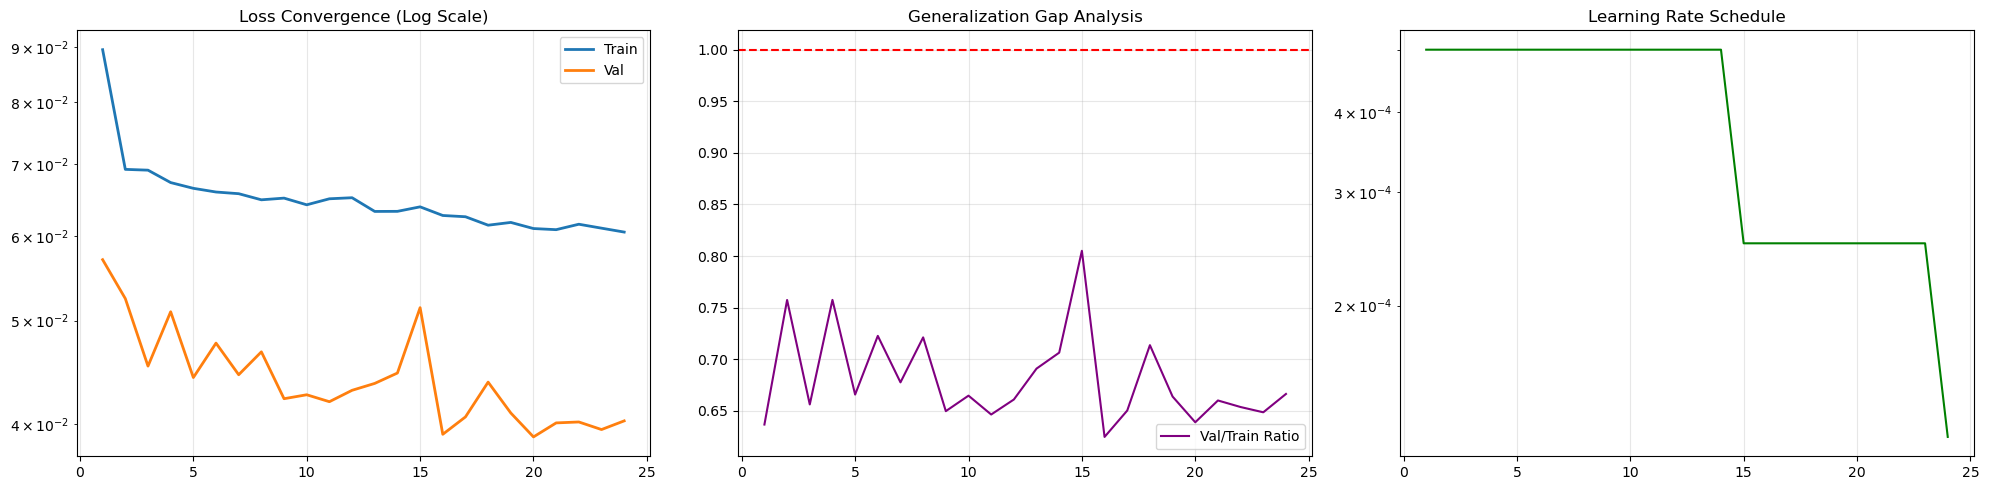

,epoch,train_loss,val_loss,lr,gap_percent
0,1,0.089505,0.056990,5.00e-04,-36.33%
12,13,0.063216,0.043678,5.00e-04,-30.91%
19,20,0.060933,0.038932,2.50e-04,-36.11%
23,24,0.060473,0.040298,1.25e-04,-33.36%


,Value
Final Validation Loss,0.040298
Min Validation Loss,0.038932
Training Volatility (Final 5),0.001384
Learning Rate Decay Factor,4.000000
Total Epochs Processed,24.000000


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import json
from IPython.display import display, HTML

def visualize_training_results(log_dir="logs", eval_dir="evaluation_results"):
    # Find the most recent experiment run
    all_runs = glob.glob(os.path.join(log_dir, "*"))
    if not all_runs:
        print("Error: No logs found.")
        return
    
    latest_run = max(all_runs, key=os.path.getmtime)
    csv_path = os.path.join(latest_run, "history.csv")
    
    if not os.path.exists(csv_path):
        print(f"Error: File {csv_path} not found.")
        return

    df = pd.read_csv(csv_path)
    print(f"Experiment Analysis: {os.path.basename(latest_run)}")

    # PANEL 1: Training Dynamics and Stability
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Loss Curves plotting logic
    axes[0].plot(df['epoch'], df['train_loss'], label='Train', color='#1f77b4', lw=2)
    axes[0].plot(df['epoch'], df['val_loss'], label='Val', color='#ff7f0e', lw=2)
    axes[0].set_title('Loss Convergence (Log Scale)', fontsize=12)
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Generalization Gap visualization
    ratio = df['val_loss'] / df['train_loss']
    axes[1].plot(df['epoch'], ratio, color='purple', label='Val/Train Ratio')
    axes[1].axhline(y=1.0, color='r', linestyle='--')
    axes[1].set_title('Generalization Gap Analysis', fontsize=12)
    axes[1].fill_between(df['epoch'], 1, ratio, where=(ratio > 1), color='purple', alpha=0.1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Learning Rate tracking
    if 'lr' in df.columns:
        axes[2].plot(df['epoch'], df['lr'], color='green')
        axes[2].set_yscale('log')
        axes[2].set_title('Learning Rate Schedule', fontsize=12)
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # TABLE 1: Training milestones summary
    display(HTML("<h4>Training Stages Summary Table</h4>"))
    best_idx = df['val_loss'].idxmin()
    points = sorted(list(set([0, len(df)//2, best_idx, len(df)-1])))
    history_summary = df.iloc[points].copy()
    history_summary['gap_percent'] = (history_summary['val_loss'] / history_summary['train_loss'] - 1) * 100
    display(history_summary.style.format({
        'train_loss': '{:.6f}', 'val_loss': '{:.6f}', 
        'lr': '{:.2e}', 'gap_percent': '{:.2f}%'
    }).background_gradient(subset=['val_loss'], cmap='Blues_r'))

    # PANEL 2: Baseline Comparison Logic
    eval_files = glob.glob(os.path.join(eval_dir, "**/test_report_deterministic.json"), recursive=True)
    
    if eval_files:
        latest_eval = max(eval_files, key=os.path.getmtime)
        with open(latest_eval, 'r') as f:
            report = json.load(f)
        
        nn = report['Neural_Network']
        base = report['Classical_Baseline']
        
        groups = {
            "Accuracy (Higher Better)": ['F1', 'IoU', 'R2', 'Cosine_Sim', 'SSIM'],
            "Error (Lower Better)": ['RMSE', 'MAE', 'Wasserstein_Dist'],
            "Localization (Lower Better)": ['LE_Max_px', 'CME_px']
        }

        fig, axes = plt.subplots(1, 3, figsize=(22, 6))
        for i, (title, m_list) in enumerate(groups.items()):
            available = [m for m in m_list if m in nn]
            if not available: continue
            x = np.arange(len(available))
            width = 0.35
            axes[i].bar(x - width/2, [nn[m] for m in available], width, label='NN Model', color='navy')
            axes[i].bar(x + width/2, [base[m] for m in available], width, label='Baseline', color='gray', alpha=0.5)
            axes[i].set_title(title)
            axes[i].set_xticks(x)
            axes[i].set_xticklabels(available, rotation=20)
            axes[i].legend()
            axes[i].grid(axis='y', alpha=0.3)

        plt.suptitle(f"Metric Comparison: NN vs Baseline (Source: {os.path.basename(os.path.dirname(latest_eval))})", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # TABLE 2: Detailed metric improvement analysis
        display(HTML("<h4>Detailed Metric Comparison Analysis</h4>"))
        
        comparison_data = []
        for cat, m_list in groups.items():
            for m in m_list:
                if m in nn:
                    v_nn = nn[m]
                    v_base = base[m]
                    if cat == "Accuracy (Higher Better)":
                        improvement = (v_nn - v_base) / (abs(v_base) + 1e-8) * 100
                    else:
                        improvement = (v_base - v_nn) / (abs(v_base) + 1e-8) * 100
                    
                    comparison_data.append({
                        "Category": cat,
                        "Metric": m,
                        "NN_Model": v_nn,
                        "Baseline": v_base,
                        "Improvement_pct": improvement
                    })
        
        comp_df = pd.DataFrame(comparison_data)
        display(comp_df.style.format({
            'NN_Model': '{:.4f}', 'Baseline': '{:.4f}', 'Improvement_pct': '{:+.2f}%'
        }).background_gradient(subset=['Improvement_pct'], cmap='RdYlGn'))

        visualize_radar(nn, base)

    # PANEL 3: Stability and Volatility Analysis
    display(HTML("<h4>Stability and Convergence Analysis</h4>"))
    
    df['loss_volatility'] = df['val_loss'].rolling(window=5).std()
    
    stability_stats = {
        "Final Validation Loss": df['val_loss'].iloc[-1],
        "Min Validation Loss": df['val_loss'].min(),
        "Training Volatility (Final 5)": df['loss_volatility'].iloc[-5:].mean(),
        "Learning Rate Decay Factor": df['lr'].iloc[0] / df['lr'].iloc[-1],
        "Total Epochs Processed": len(df)
    }
    
    stab_df = pd.DataFrame([stability_stats]).T.rename(columns={0: "Value"})
    display(stab_df.style.format(precision=6))

def visualize_radar(nn_metrics, base_metrics):
    # Radar chart generation logic
    radar_metrics = ['F1', 'IoU', 'R2', 'SSIM', 'Pearson_r', 'Cosine_Sim']
    labels = [m for m in radar_metrics if m in nn_metrics]
    
    nn_vals = [nn_metrics.get(m, 0) for m in labels]
    base_vals = [base_metrics.get(m, 0) for m in labels]

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    nn_vals += nn_vals[:1]; base_vals += base_vals[:1]; angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.fill(angles, nn_vals, color='blue', alpha=0.2, label='Neural Network')
    ax.plot(angles, nn_vals, color='blue', linewidth=2)
    ax.fill(angles, base_vals, color='gray', alpha=0.1, label='Baseline')
    ax.plot(angles, base_vals, color='gray', linewidth=2, linestyle='--')

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title("Model Profile Balance (Normalized Metrics)", y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Execution call
visualize_training_results()

# 6 SYSTEM EVALUATION

STATUS: Searching for the best model artifact...
SELECTED_MODEL: best_model_epoch_23_loss_0.0396.pth

STATUS: Restoring configuration from checkpoint...
STATUS: Initializing test data loader...
Dataset test: 500 samples.

STATUS: Running batch numerical evaluation...

=== FINAL EVALUATION (mode: deterministic) ===

--- Classical Baseline ---
  Regression and Structure:
    RMSE:       0.2341 | MAE: 0.1405
    R2 Score:   -2.9916 | Pearson_r: 0.0197
    SSIM:       0.2035 | PSNR: 12.64 dB
    Wasserstein:0.0560
  Epicenter Localization:
    LE_Max_px:  29.4 px (Absolute maximum error)
    CME_px:     20.6 px (Cloud center of mass error)
  Zone Segmentation (Threshold=0.5):
    F1 Score:   0.0285 | IoU: 0.0154
    Precision:  0.0217 | Recall: 0.0645

--- Neural Network Model (NN) ---
  Regression and Structure:
    RMSE:       0.1087 | MAE: 0.0646
    R2 Score:   0.2300 | Pearson_r: 0.6434
    SSIM:       0.3805 | PSNR: 19.54 dB
    Wasserstein:0.0566
  Epicenter Localization:
    LE_Max

STATUS: Collecting 3 unique scenarios for visualization...


Environmental Conditions: Wind Speed = 6.31 m/s


,Value
Metric,
RMSE,0.0744
R2,0.3575
SSIM,0.4729
F1,0.0000
IoU,0.0000
Max_Pred,0.4270
Max_True,1.0000
CME_px,4.46


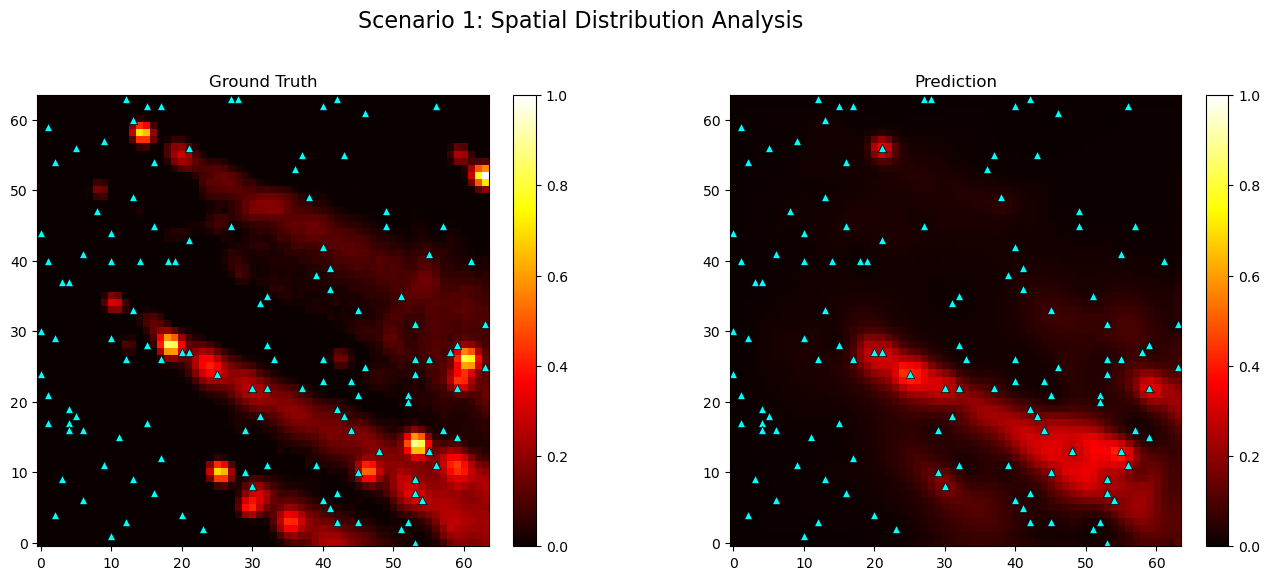

----------------------------------------------------------------------------------------------------


Environmental Conditions: Wind Speed = 1.03 m/s


,Value
Metric,
RMSE,0.1035
R2,0.3651
SSIM,0.4661
F1,0.0571
IoU,0.0294
Max_Pred,0.5621
Max_True,1.0000
CME_px,4.34


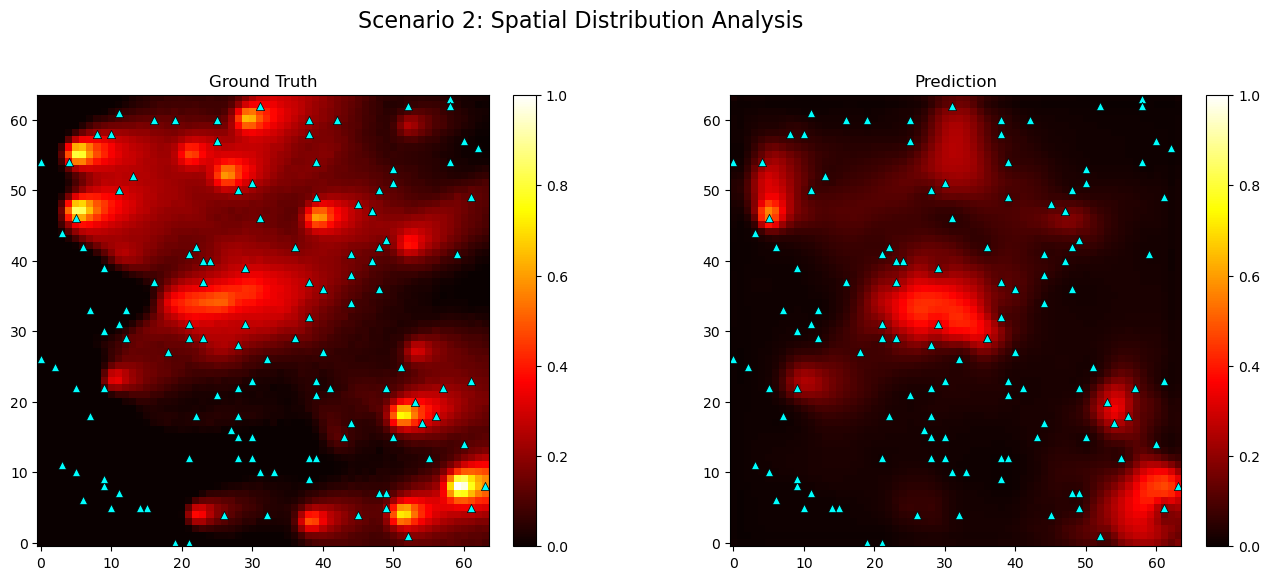

----------------------------------------------------------------------------------------------------


Environmental Conditions: Wind Speed = 3.09 m/s


,Value
Metric,
RMSE,0.0877
R2,0.4189
SSIM,0.4115
F1,0.0000
IoU,0.0000
Max_Pred,0.5852
Max_True,1.0000
CME_px,5.69


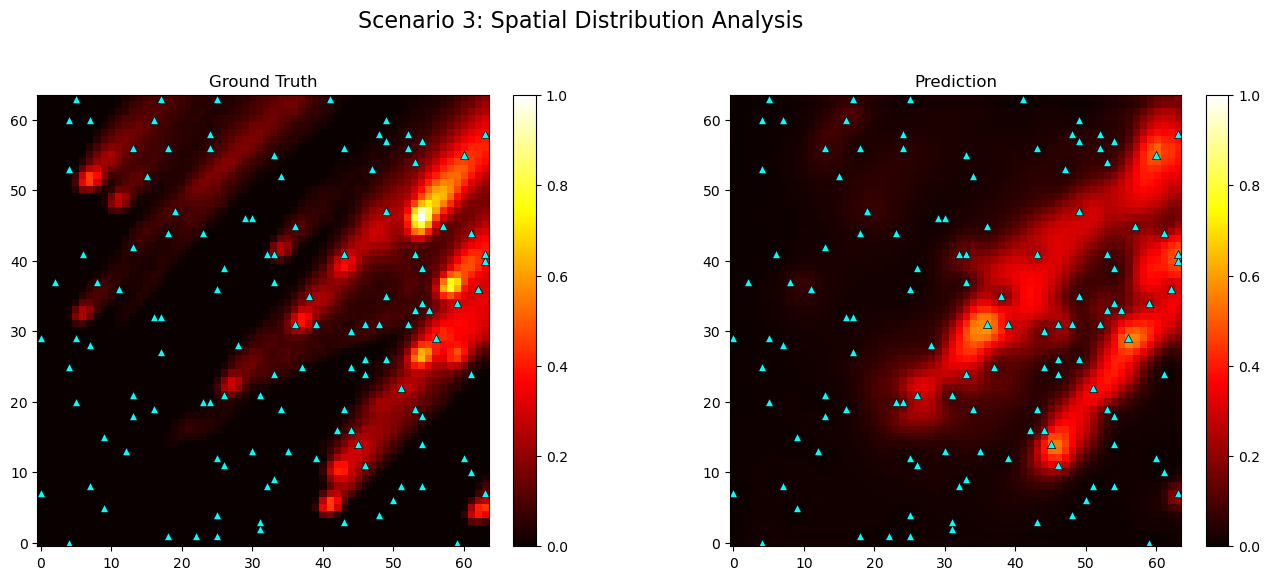

----------------------------------------------------------------------------------------------------


In [6]:
import os
import torch
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from IPython.display import display, HTML

# Module-specific imports for evaluation and visualization
from src.pollution_predictor.evaluation.visualizer import plot_results
from src.pollution_predictor.evaluation.metrics import evaluate_predictions
from src.pollution_predictor.config.configs import AppConfig
from src.pollution_predictor.data.dataset import PollutionStreamingDataset
from src.pollution_predictor.inference.predictor import InferencePredictor
from src.pollution_predictor.evaluation.evaluator import SystemEvaluator
from src.pollution_predictor.tracking.checkpointing import CheckpointManager

# --- STEP 1: MODEL ARTIFACT DISCOVERY ---
print("STATUS: Searching for the best model artifact...")
checkpoint_dir = "checkpoints/V2_Enhanced"
all_checkpoints = glob.glob(os.path.join(checkpoint_dir, "best_model_*.pth"))

if not all_checkpoints:
    raise FileNotFoundError(f"No checkpoints found in {checkpoint_dir}")

# Select the most recent best model based on modification time
best_univ_model_path = max(all_checkpoints, key=os.path.getmtime)
print(f"SELECTED_MODEL: {os.path.basename(best_univ_model_path)}")


# --- STEP 2: CONFIGURATION RESTORATION ---
print("\nSTATUS: Restoring configuration from checkpoint...")
device = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint = CheckpointManager.load(best_univ_model_path, device='cpu')
full_cfg = AppConfig(**checkpoint['config'])

# Path to the master dataset for testing
test_h5_path = "data/universal_master_train.h5" 


# --- STEP 3: PREDICTOR INITIALIZATION ---
predictor = InferencePredictor(best_univ_model_path, device=device)


# --- STEP 4: TEST DATA LOADER INITIALIZATION ---
print("STATUS: Initializing test data loader...")
test_ds = PollutionStreamingDataset(
    config=full_cfg.data, 
    h5_path=test_h5_path, 
    transforms=predictor.transforms, 
    mode='test'
)

# Standard DataLoader setup for batch processing
test_loader = DataLoader(
    test_ds, 
    batch_size=full_cfg.data.batch_size, 
    num_workers=full_cfg.data.num_workers
)


# --- STEP 5: NUMERICAL BATCH EVALUATION ---
print("\nSTATUS: Running batch numerical evaluation...")
output_eval_dir = os.path.join("evaluation_results", full_cfg.tracker.experiment_name)
evaluator = SystemEvaluator(
    predictor=predictor, 
    test_loader=test_loader, 
    output_dir=output_eval_dir
)
evaluator.run_evaluation(use_stochastic=False)


# --- STEP 6: VISUAL ANALYSIS OF DIVERSE SCENARIOS ---
display(HTML("<h2>Visual Analysis: Diverse Scenario Comparison</h2>"))
num_examples_to_show = 3

print(f"STATUS: Collecting {num_examples_to_show} unique scenarios for visualization...")

unique_samples = []
loader_iter = iter(test_loader)

# Collect one sample from each batch to ensure spatial diversity
while len(unique_samples) < num_examples_to_show:
    try:
        batch = next(loader_iter)
        unique_samples.append({
            'readings': batch['readings'][0:1].to(device),
            'coords': batch['coords'][0:1].to(device),
            'target': batch['target'][0:1].to(device),
            'wind': batch.get('wind', None)[0:1].to(device) if 'wind' in batch else None
        })
    except StopIteration:
        break

# Process and visualize each collected sample
for i, sample in enumerate(unique_samples):
    predictor.model.eval()
    
    with torch.no_grad():
        # Perform inference using prepared data
        y_pred_tensor = predictor.model(sample)
        
        # Convert tensors to numpy for analysis and plotting
        y_true = sample['target'].cpu().numpy()[0, 0]
        y_pred = y_pred_tensor.cpu().numpy()[0, 0]
        coords = sample['coords'].cpu().numpy()[0]
        
        # Environmental conditions logging
        w_speed_str = "N/A"
        if sample['wind'] is not None:
            # Scale wind back to physical units
            w_raw = sample['wind'].cpu().numpy()[0] * predictor.transforms.max_wind_speed
            w_speed_str = f"{np.linalg.norm(w_raw):.2f} m/s"

    # Compute per-sample metrics
    m = evaluate_predictions(y_true, y_pred)
    
    # Render diagnostic report header
    display(HTML(f"<h3>Scenario {i+1} Diagnostic Report</h3>"))
    print(f"Environmental Conditions: Wind Speed = {w_speed_str}")
    
    # Metric summary table construction
    metrics_data = {
        "Metric": ["RMSE", "R2", "SSIM", "F1", "IoU", "Max_Pred", "Max_True", "CME_px"],
        "Value": [
            f"{m.get('RMSE', 0):.4f}",
            f"{m.get('R2', 0):.4f}",
            f"{m.get('SSIM', 0):.4f}",
            f"{m.get('F1', 0):.4f}",
            f"{m.get('IoU', 0):.4f}",
            f"{y_pred.max():.4f}",
            f"{y_true.max():.4f}",
            f"{m.get('CME_px', 0):.2f}"
        ]
    }
    
    display(pd.DataFrame(metrics_data).set_index("Metric"))
    
    # Render spatial comparison plots
    plot_results(
        y_true=y_true, 
        y_pred=y_pred, 
        coords=coords, 
        metrics=m,
        title=f"Scenario {i+1}: Spatial Distribution Analysis"
    )
    print("-" * 100)

# 7 BASE ANALYTICAL ARCHITECTURAL DIAGNOSTICS

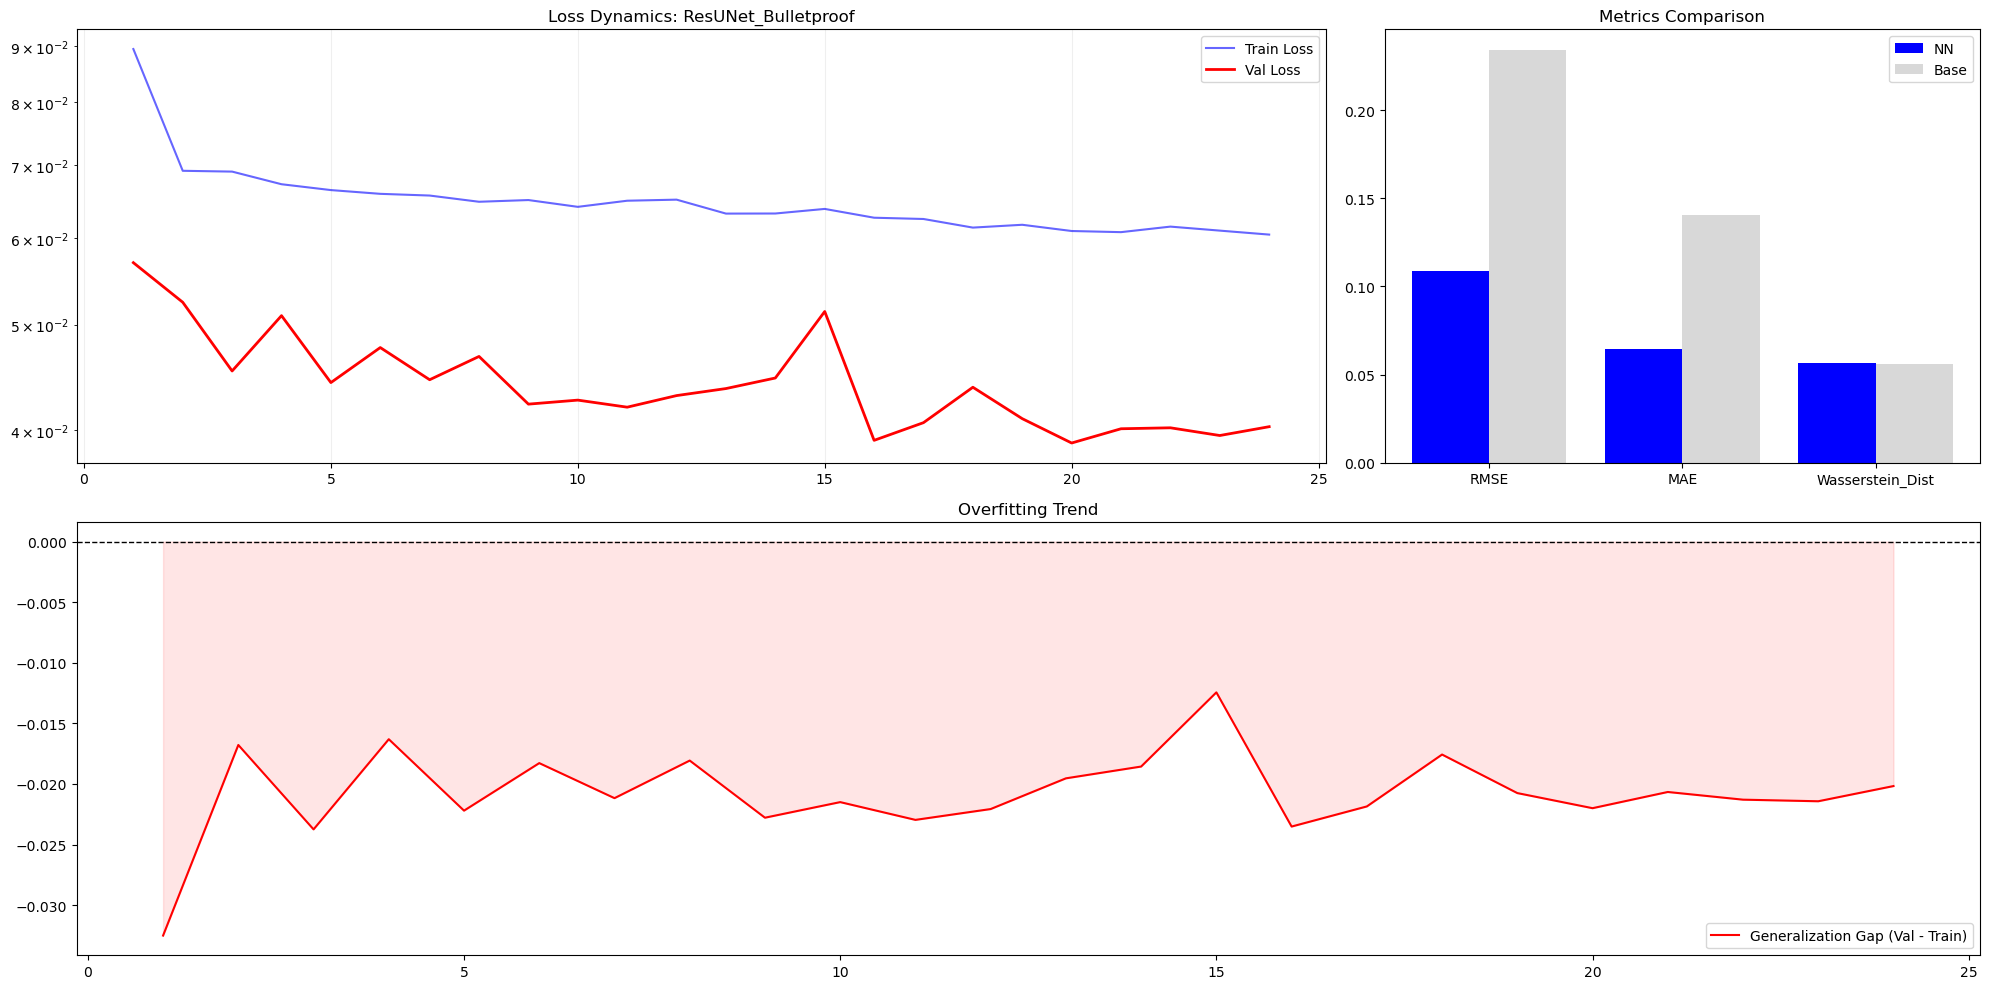

,RMSE,MAE,Max_Error,sMAPE,R2,Pearson_r,PSNR,SSIM,Cosine_Sim,Wasserstein_Dist,LE_Max_px,CME_px,IoU,F1,Precision,Recall,Specificity
Neural_Network,0.1087,0.0646,0.8527,141.5748,0.2300,0.6434,19.5397,0.3805,0.7535,0.0566,22.7408,5.7569,0.0714,0.1229,0.4322,0.0836,0.9984
Classical_Baseline,0.2341,0.1405,0.9823,171.4546,-2.9916,0.0197,12.6358,0.2035,0.2510,0.0560,29.4138,20.6218,0.0154,0.0285,0.0217,0.0645,0.9328


,epoch,train_loss,val_loss,lr
19,20,0.060933,0.038932,2.50000000e-04
20,21,0.060786,0.040122,2.50000000e-04
21,22,0.061501,0.040203,2.50000000e-04
22,23,0.060983,0.039553,2.50000000e-04
23,24,0.060473,0.040298,1.25000000e-04


- UNDERFITTING: Train loss is higher than validation loss. The model is too weak. Increase hidden_dim or the number of layers.
- STRUCTURAL DEFICIT: Low SSIM detected. The model fails to reproduce spatial morphology. Residual Connections or Attention modules are recommended.


,Value
Best Val Loss,0.038932
Gap Ratio,-36.1%
Architecture,st_unet
Hidden Dim,64


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import glob
import torch
from IPython.display import display, HTML

def architectural_analysis(log_dir="logs", eval_dir="evaluation_results", ckpt_dir="checkpoints/Universal"):
    # 1. Data retrieval logic
    all_runs = glob.glob(os.path.join(log_dir, "*"))
    if not all_runs: return print("Error: No logs found.")
    latest_run = max(all_runs, key=os.path.getmtime)
    csv_path = os.path.join(latest_run, "history.csv")
    if not os.path.exists(csv_path): return print(f"Error: history.csv not found in {latest_run}")
    
    df = pd.read_csv(csv_path)
    
    # 2. Configuration loading logic (Robust loading from JSON or PTH)
    cfg = None
    config_path = os.path.join(latest_run, "config.json")
    if os.path.exists(config_path):
        with open(config_path, 'r') as f: cfg = json.load(f)
    else:
        all_ckpts = glob.glob(os.path.join(ckpt_dir, "*.pth"))
        if all_ckpts:
            ckpt_data = torch.load(max(all_ckpts, key=os.path.getmtime), map_location='cpu', weights_only=False)
            cfg = ckpt_data.get('config')
    
    if cfg is None: cfg = {"model": {"architecture": "unknown", "params": {}}, "tracker": {"experiment_name": "unknown"}}

    # 3. Evaluation report discovery logic
    eval_files = glob.glob(os.path.join(eval_dir, "**/test_report_deterministic.json"), recursive=True)
    report = None
    if eval_files:
        with open(max(eval_files, key=os.path.getmtime), 'r') as f: report = json.load(f)

    # --- VISUALIZATION BLOCK ---
    fig = plt.figure(figsize=(20, 10))
    gs = plt.GridSpec(2, 3, figure=fig)

    # A. Loss Convergence Plot
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax1.plot(df['epoch'], df['train_loss'], label='Train Loss', color='blue', alpha=0.6)
    ax1.plot(df['epoch'], df['val_loss'], label='Val Loss', color='red', lw=2)
    ax1.set_yscale('log')
    ax1.set_title(f"Loss Dynamics: {cfg['tracker'].get('experiment_name', 'Model')}")
    ax1.legend(); ax1.grid(True, alpha=0.2)

    # B. Regression Metrics Comparison Plot
    ax2 = fig.add_subplot(gs[0, 2])
    if report:
        nn, base = report['Neural_Network'], report['Classical_Baseline']
        m_names = ['RMSE', 'MAE', 'Wasserstein_Dist']
        x = np.arange(len(m_names))
        ax2.bar(x - 0.2, [nn[m] for m in m_names], 0.4, label='NN', color='blue')
        ax2.bar(x + 0.2, [base[m] for m in m_names], 0.4, label='Base', color='gray', alpha=0.3)
        ax2.set_xticks(x); ax2.set_xticklabels(m_names); ax2.set_title("Metrics Comparison")
        ax2.legend()

    # C. Generalization/Overfitting Trend Plot
    ax3 = fig.add_subplot(gs[1, :])
    gap = df['val_loss'] - df['train_loss']
    ax3.fill_between(df['epoch'], gap, color='red', alpha=0.1)
    ax3.plot(df['epoch'], gap, color='red', label='Generalization Gap (Val - Train)')
    ax3.axhline(0, color='black', lw=1, ls='--')
    ax3.set_title("Overfitting Trend")
    ax3.legend()

    plt.tight_layout(); plt.show()

    # --- TABULAR OUTPUT BLOCK ---
    display(HTML("<h3>Analytical Report</h3>"))
    
    # Table 1: Model vs Baseline accuracy
    if report:
        display(HTML("<b>Test Data Accuracy Comparison:</b>"))
        comp_df = pd.DataFrame(report).T
        display(comp_df.style.format(precision=4).background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE']))

    # Table 2: Recent training history
    display(HTML("<br><b>Last 5 Training Epochs:</b>"))
    display(df.tail(5).style.format({"train_loss": "{:.6f}", "val_loss": "{:.6f}", "lr": "{:.8e}"}))

    # 4. DIAGNOSTIC LOGIC
    display(HTML("<br><b>Architectural Conclusion:</b>"))
    best_val_loss = df['val_loss'].min()
    train_at_best = df.loc[df['val_loss'].idxmin(), 'train_loss']
    gap_ratio = (best_val_loss / (train_at_best + 1e-8)) - 1
    
    conclusions = []
    if gap_ratio < -0.10:
        conclusions.append("UNDERFITTING: Train loss is higher than validation loss. The model is too weak. Increase hidden_dim or the number of layers.")
    elif gap_ratio > 0.25:
        conclusions.append("OVERFITTING: Significant gap between training and validation. Increase Dropout or decrease network complexity.")
    
    if report and nn.get('SSIM', 0) < 0.4:
        conclusions.append("STRUCTURAL DEFICIT: Low SSIM detected. The model fails to reproduce spatial morphology. Residual Connections or Attention modules are recommended.")

    if not conclusions:
        print("Model Status: Stable. No significant architectural changes required.")
    else:
        for c in conclusions: print(f"- {c}")

    # Summary statistics table
    stats = {
        "Best Val Loss": f"{best_val_loss:.6f}",
        "Gap Ratio": f"{gap_ratio*100:.1f}%",
        "Architecture": cfg['model'].get('architecture', 'N/A'),
        "Hidden Dim": cfg['model'].get('params', {}).get('hidden_dim', 'N/A')
    }
    display(pd.DataFrame([stats]).T.rename(columns={0: "Value"}))

# Execution
architectural_analysis()

# Generated scenario visualizer logic

Starting comprehensive dataset analysis...
--- Analysis Dashboard: scenario_0000 ---


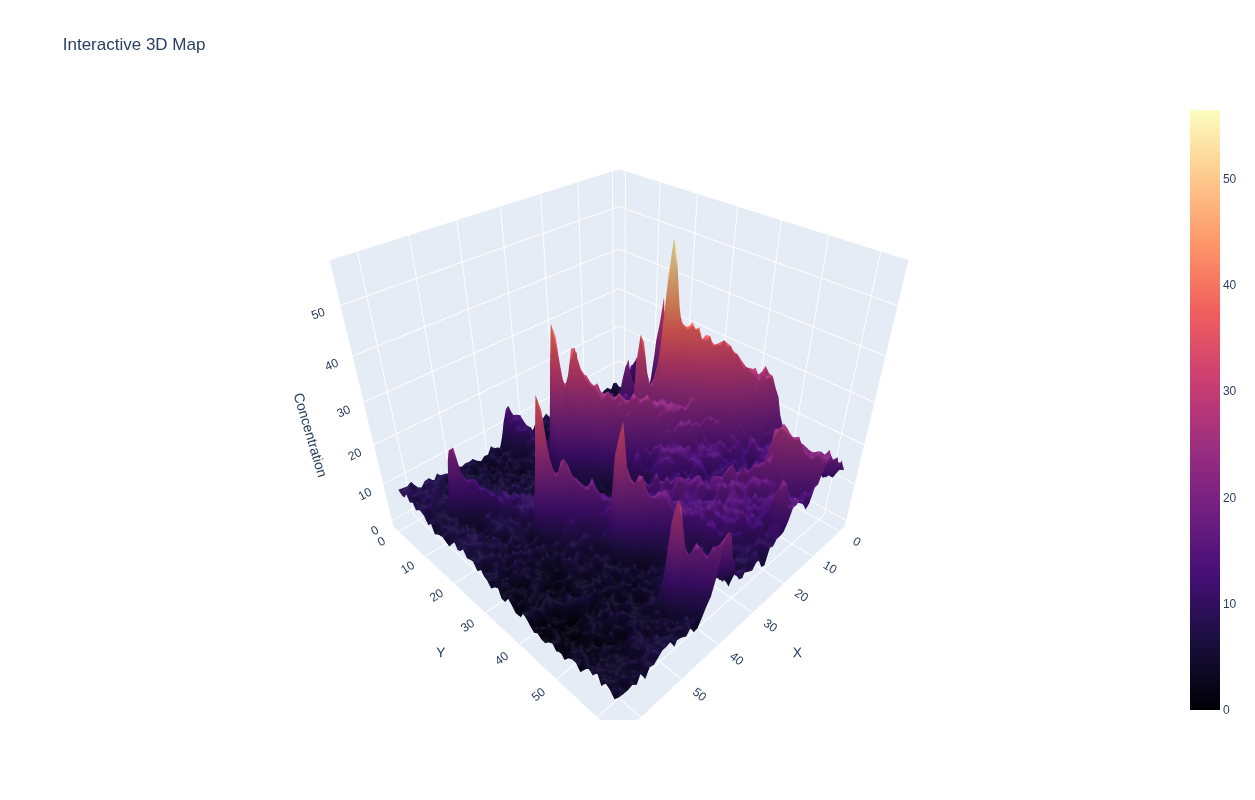

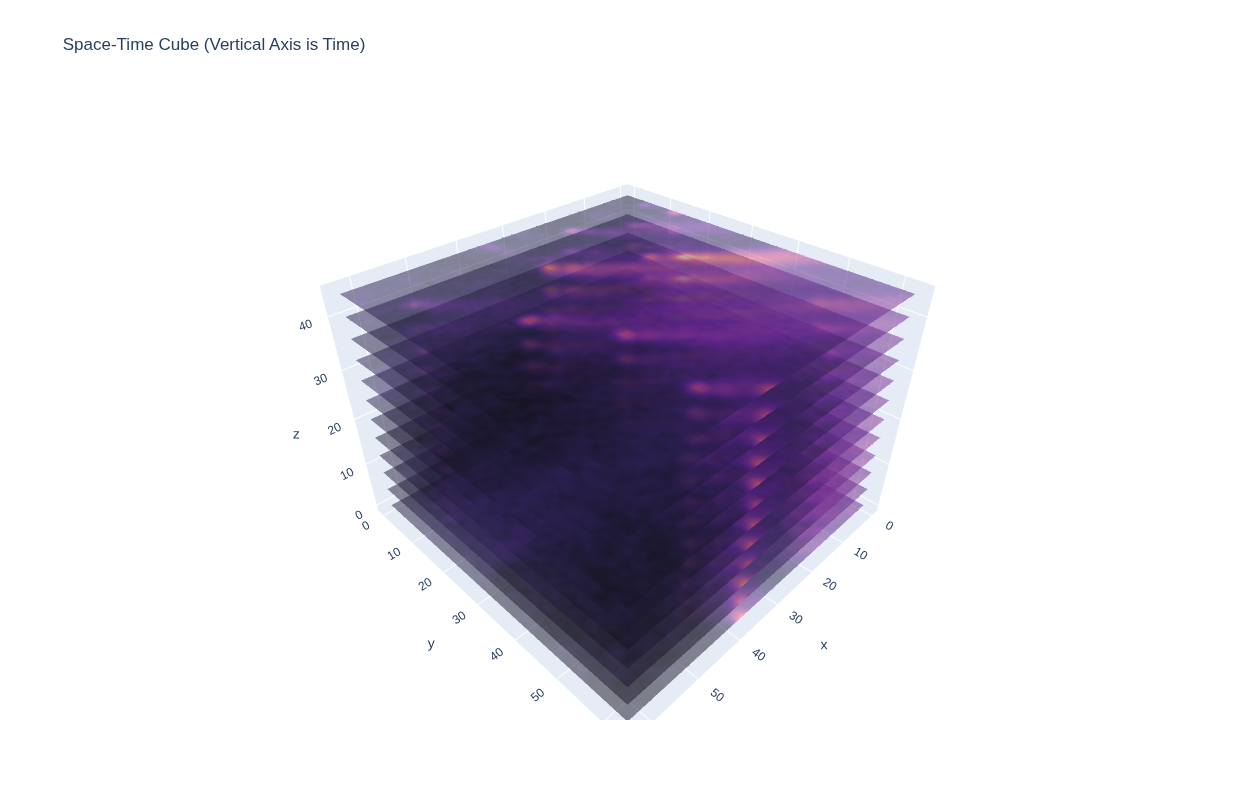

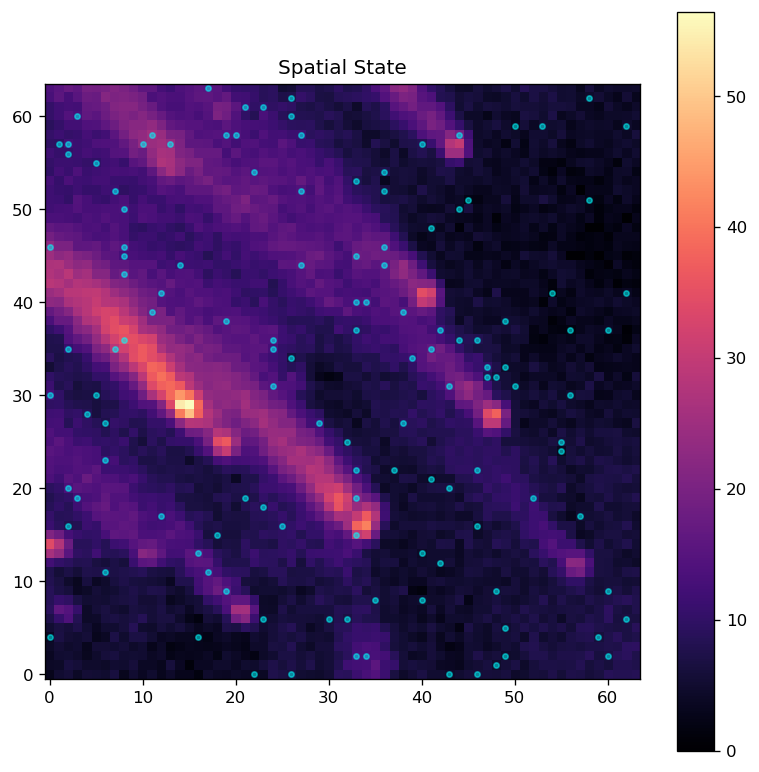

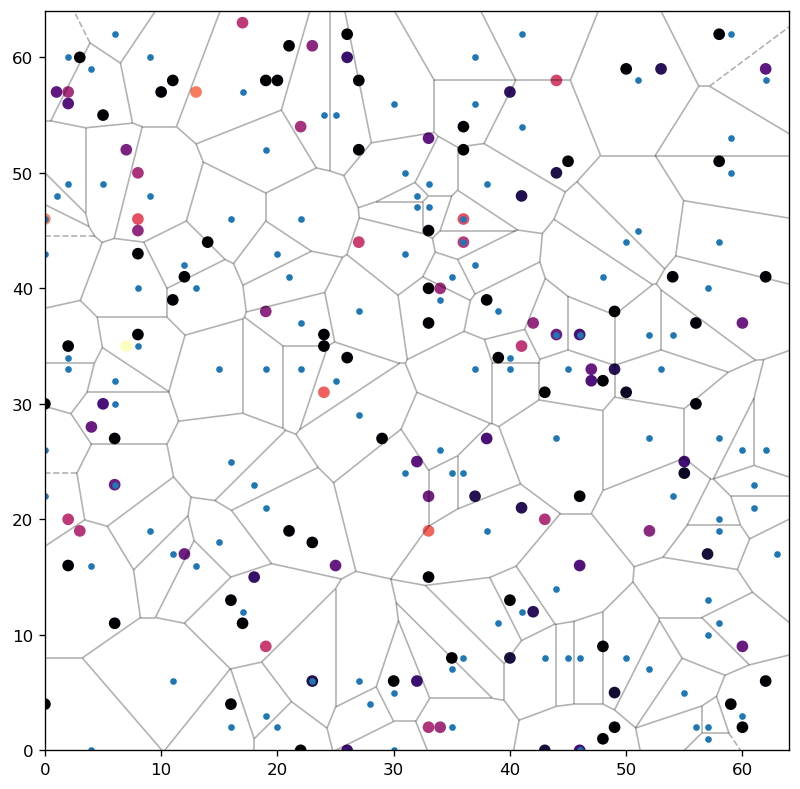

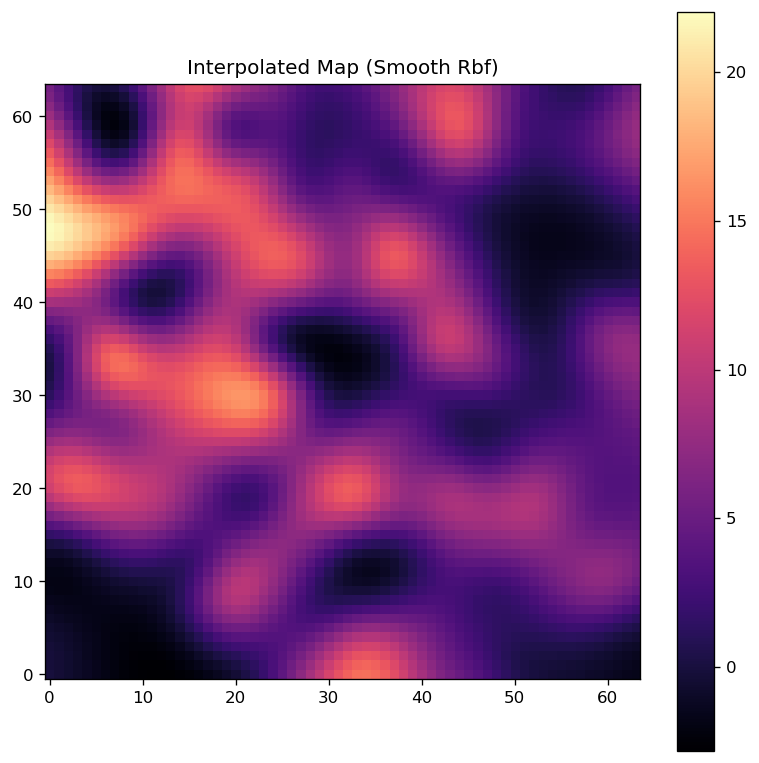

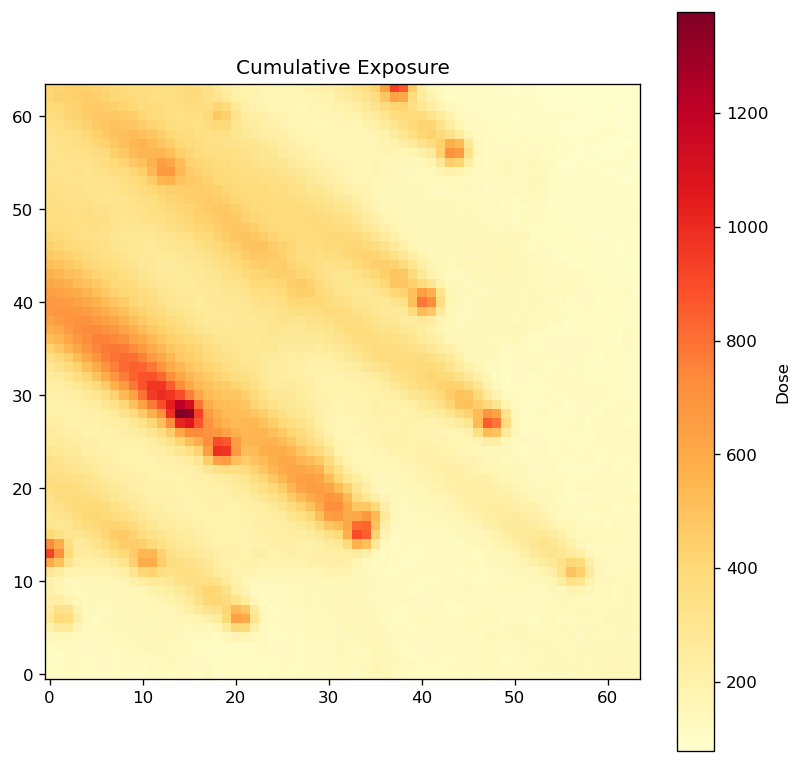

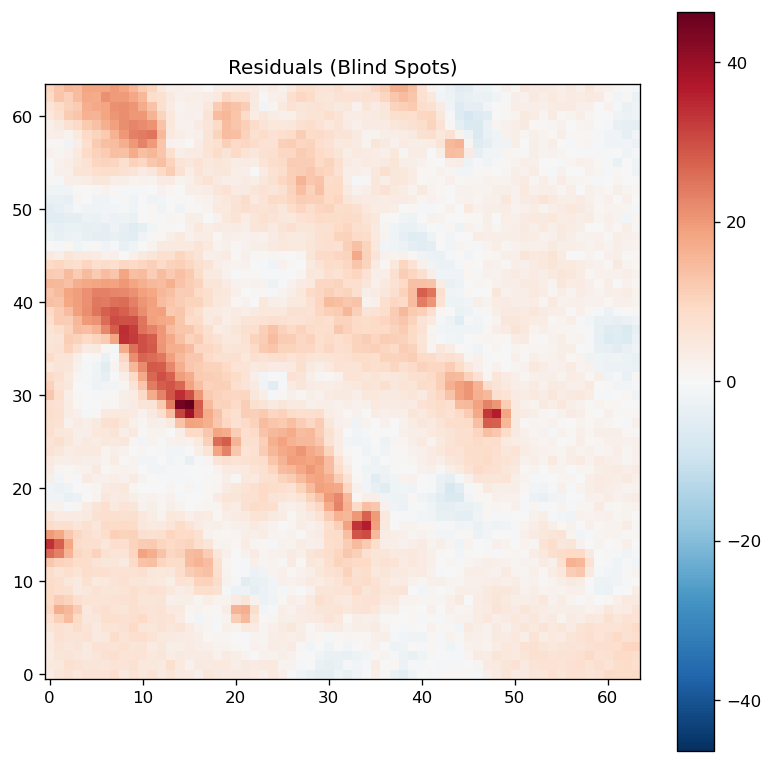

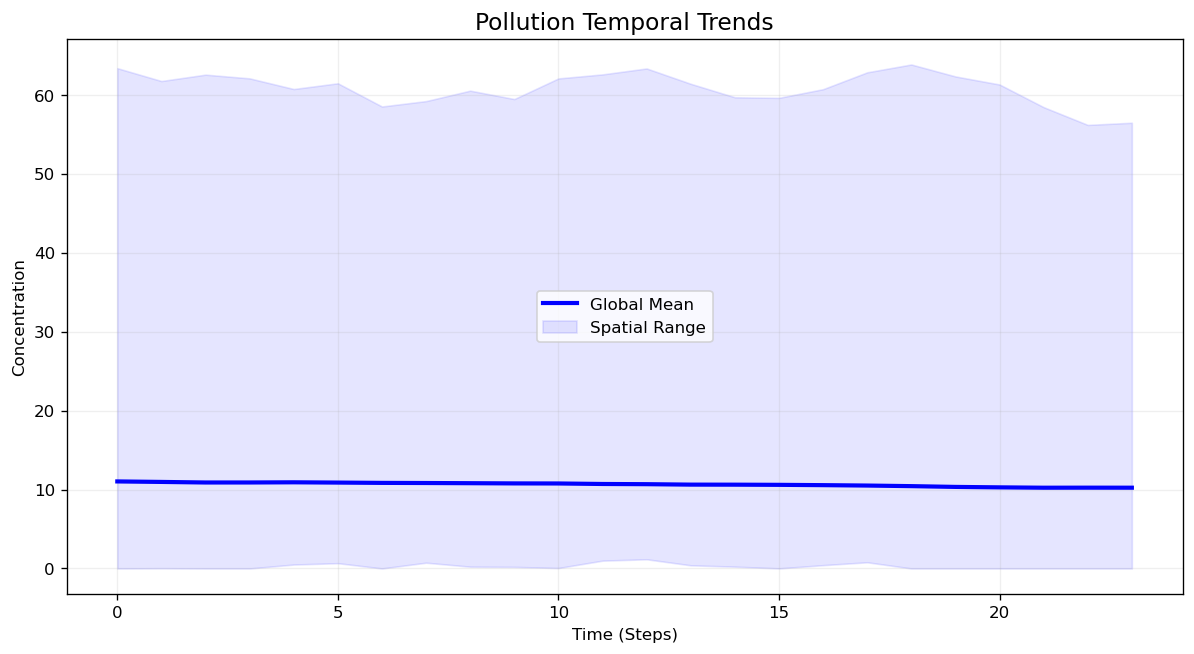

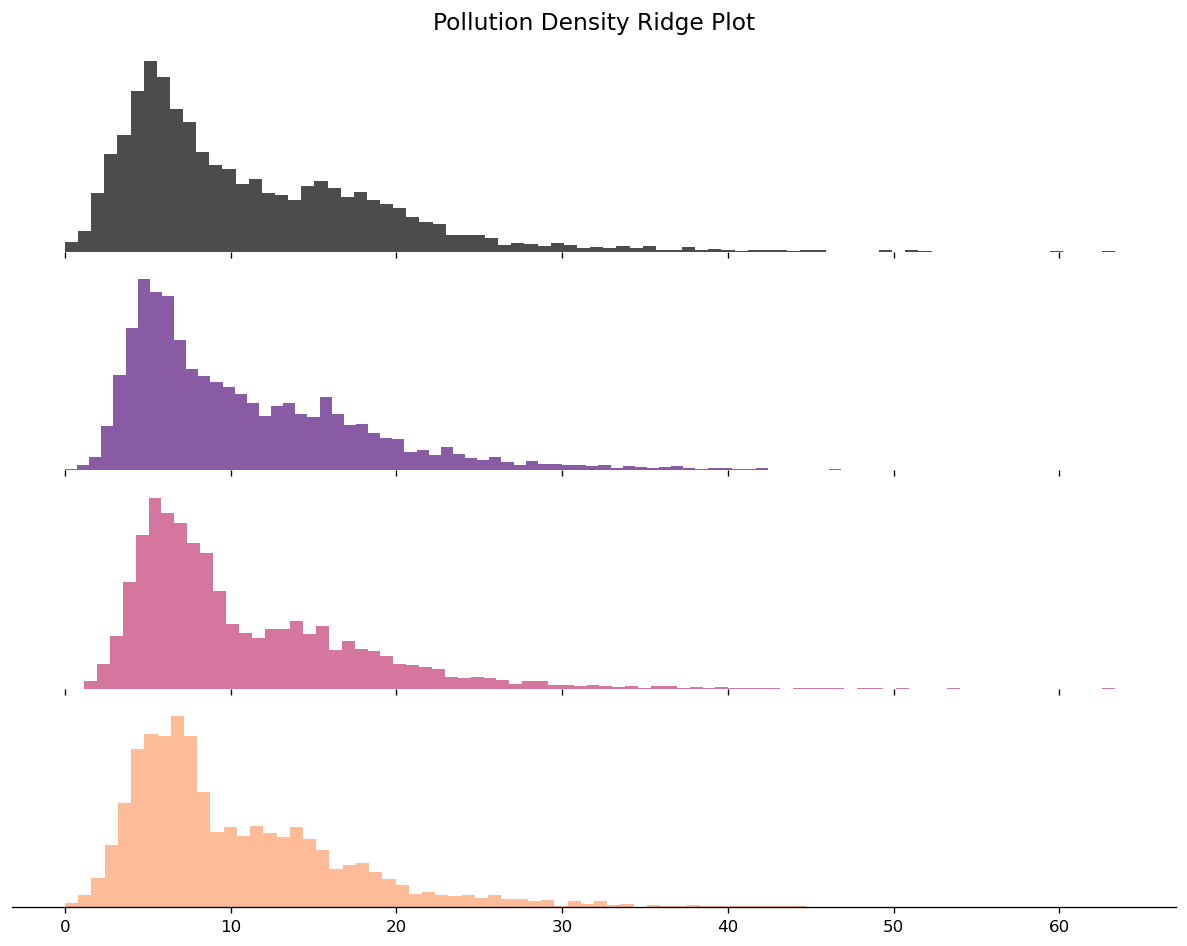

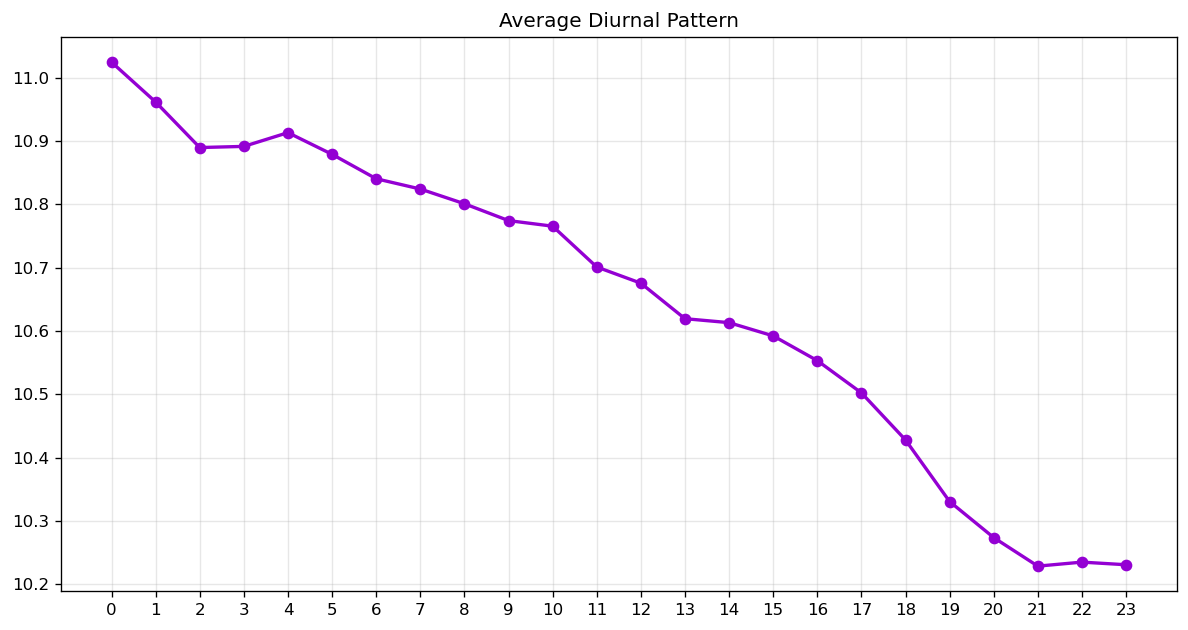

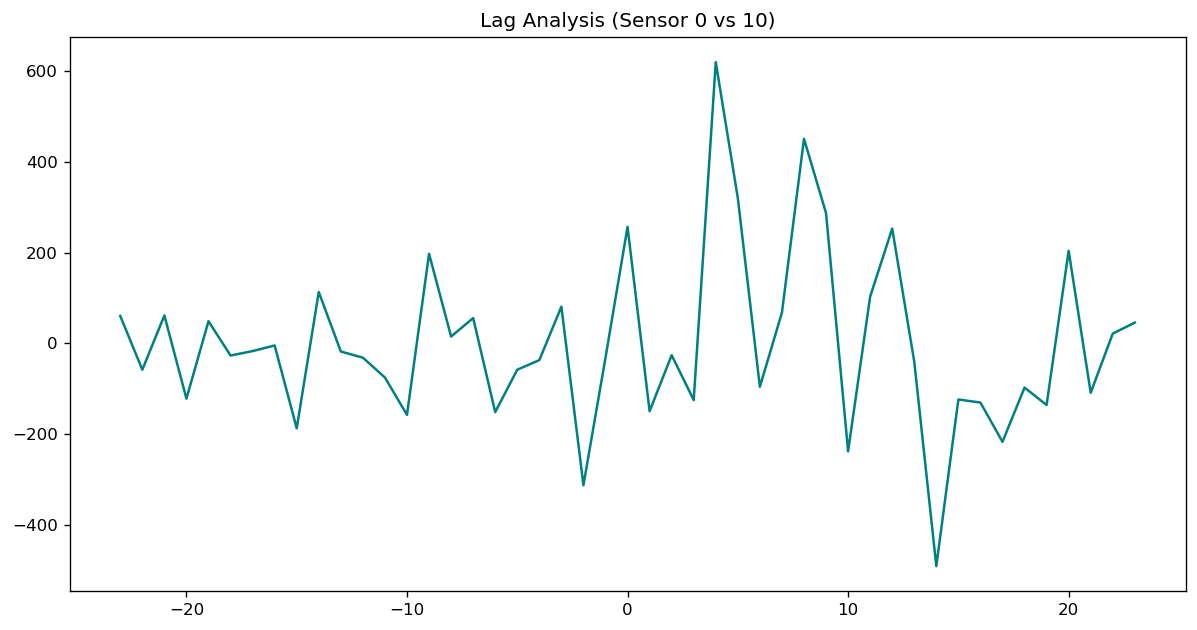

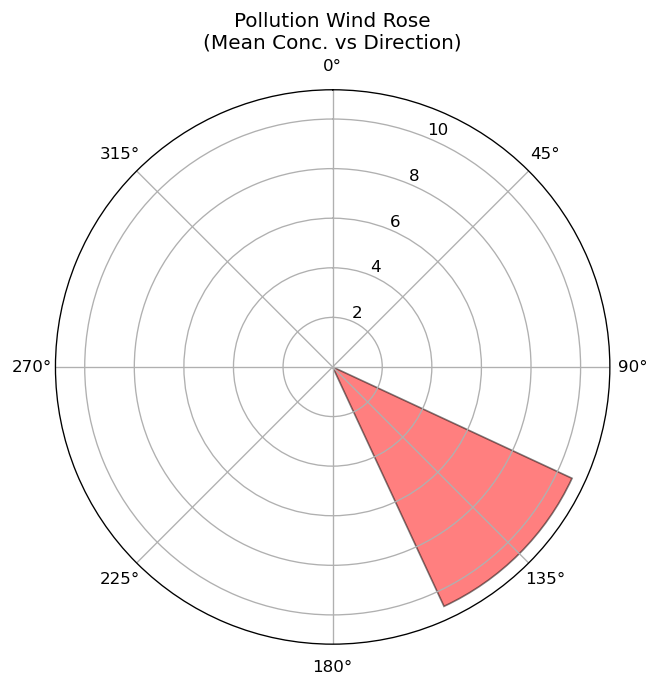

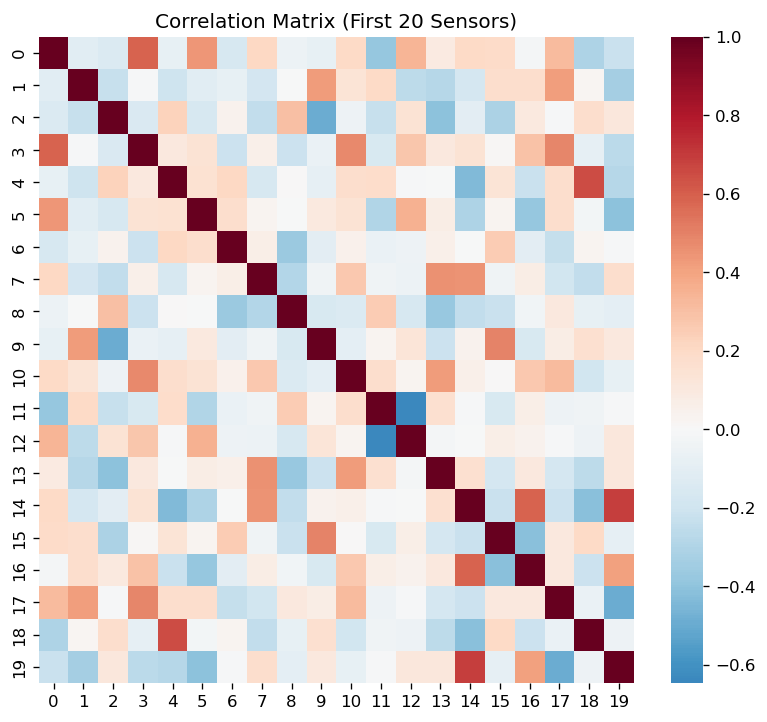

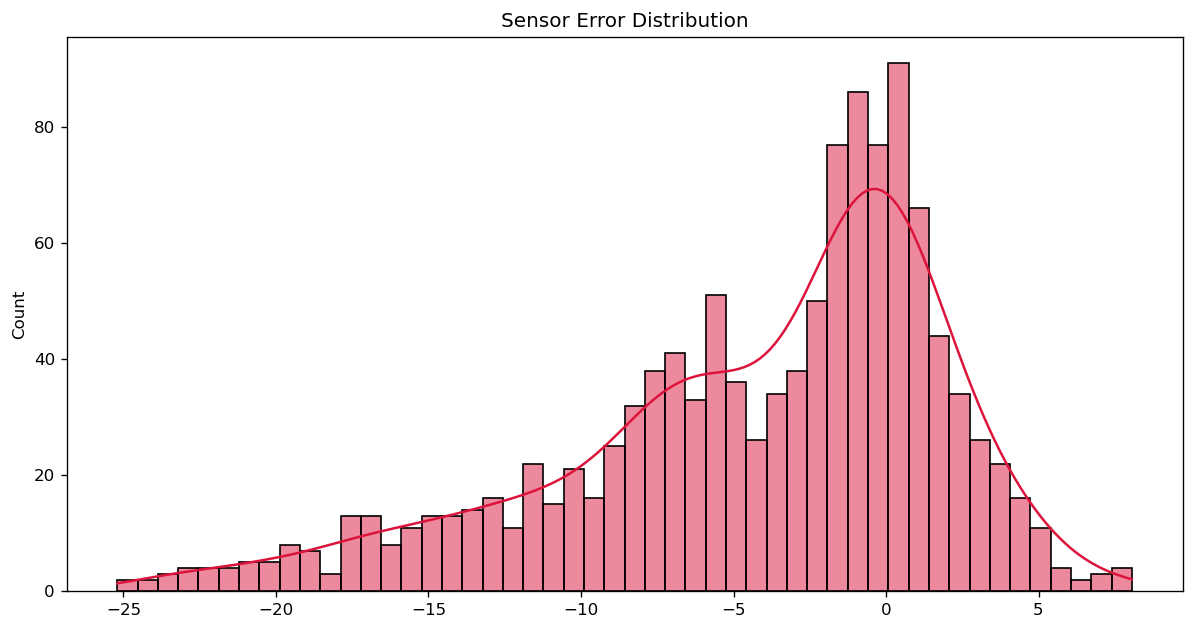

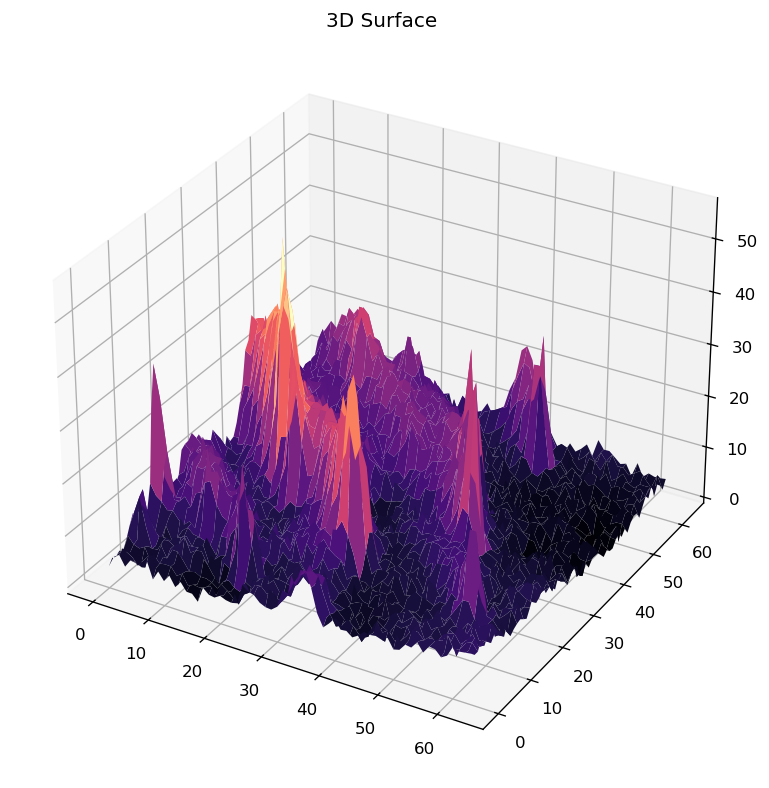


Generating GIF animation of pollution dynamics...
Saving animation to full_simulation_demo.gif...
Animation saved successfully.
Done! Check your working directory for 'full_simulation_demo.gif'


In [8]:
from src.pollution_visualizer.engine import DataVisualizer
from src.pollution_visualizer.config import VisConfig

# =================================================================
# 1. VISUAL STYLE FINE-TUNING (VisConfig)
# =================================================================
# Initialize stylistic parameters for high-fidelity reporting
custom_vis_config = VisConfig(
    cmap_main="magma",       # Primary heatmap colormap (options: inferno, viridis, plasma, magma)
    cmap_div="RdBu_r",       # Divergent colormap for residuals and correlations (red/blue)
    sensor_color="#00ffff",  # Cyan marker color for sensor locations
    dpi=120,                 # Resolution for exported graphics
    figsize_std=(12, 6),     # Standard plot aspect ratio
    figsize_square=(8, 8),   # Aspect ratio for spatial heatmaps
    figsize_wide=(18, 5),    # Aspect ratio for long time-series
    title_fontsize=14        # Font size for plot headers
)

# Instantiate the visualization engine
viz = DataVisualizer(custom_vis_config)

# Define dataset path
DATASET_FILE = "data/universal_master_train.h5"

# =================================================================
# 2. BATCH ANALYSIS DISPATCH (analyze method)
# =================================================================

# Comprehensive list of available visualization keys
all_possible_plots = [
    # --- Spatial Metrics ---
    'spatial',        # 2D Heatmap + sensor overlay + wind vector
    'voronoi',        # Sensor coverage zones (Voronoi tessellation)
    'interp',         # Map reconstructed via mathematical interpolation
    'dose',           # Cumulative exposure map (Integral over time)
    'residuals',      # Error map (Ground Truth minus Interpolation)
    
    # --- Temporal Metrics ---
    'trends',         # Global Mean/Min/Max temporal trends
    'ridge',          # Ridge plot (Hourly concentration distribution cascade)
    'diurnal',        # Diurnal pattern analysis (00:00 - 23:00 aggregation)
    'lag',            # Signal delay analysis between sensor nodes
    
    # --- Statistical Metrics ---
    'corr',           # Inter-sensor correlation matrix
    'errors',         # Measurement error distribution (Noise + Drift)
    'wind_rose',      # Concentration dependency on wind direction
    
    # --- 3D & Interactive Modules ---
    '3d',             # Static Matplotlib 3D surface
    'interactive_3d', # Rotatable Plotly 3D map
    'st_cube'         # Space-Time Cube (Vertical Z-axis mapped to Time)
]

print("Starting comprehensive dataset analysis...")

# Execute multi-faceted diagnostic reporting
viz.analyze(
    file_path=DATASET_FILE, 
    scenario_idx=0,           # Target scenario index (0 to NUM_SCENARIOS-1)
    layout_idx=0,             # Sensor topology index (0 to NUM_LAYOUTS-1)
    plots=all_possible_plots,  # Dispatch all visualization modules
    time_range=(0, 72)        # Temporal limit (start_hour, end_hour). None = full range.
)

# =================================================================
# 3. ANIMATION RENDERER (animate method)
# =================================================================

print("\nGenerating GIF animation of pollution dynamics...")

# Export temporal evolution to a GIF file
viz.animate(
    file_path=DATASET_FILE,
    scenario_idx=0,
    output_path="full_simulation_demo.gif",
    fps=12                    # Animation frames per second
)

print("Done! Check your working directory for 'full_simulation_demo.gif'")

# Module Analyzer Logic

In [ ]:
import os

def print_project_structure_and_content(root_dir, ignore_prefixes=('.', '__')):
    """
    Prints the project directory tree and the content of relevant source files.
    ignore_prefixes: Tuple of prefixes to skip (e.g., ('.', '__')).
    """
    print(f"=== PROJECT STRUCTURE: {root_dir} ===")
    print(f"(Ignoring folders starting with: {ignore_prefixes})\n")
    
    # 1. Directory tree traversal logic
    for root, dirs, files in os.walk(root_dir):
        # Modify dirs in-place to prevent os.walk from entering ignored subdirectories
        dirs[:] = [d for d in dirs if not d.startswith(ignore_prefixes)]
        
        level = root.replace(root_dir, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}[D] {os.path.basename(root)}/")
        
        sub_indent = ' ' * 4 * (level + 1)
        for f in files:
            print(f"{sub_indent}[F] {f}")

    print("\n" + "="*60)
    print("=== FILE CONTENT (EXCLUDING IGNORED FOLDERS) ===")
    print("="*60 + "\n")

    # 2. File content extraction logic
    for root, dirs, files in os.walk(root_dir):
        # Filter directories again to skip hidden/ignored content
        dirs[:] = [d for d in dirs if not d.startswith(ignore_prefixes)]
        
        for f in files:
            # Filter for specific text-based extensions and exclude package initializers
            if f.endswith(('.py', '.json', '.txt')) and f != '__init__.py':
                file_path = os.path.join(root, f)
                print(f"--- FILE: {file_path} ---")
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        content = file.read()
                        if content.strip():
                            print(content)
                        else:
                            print("[Empty file]")
                except Exception as e:
                    print(f"[Read error: {e}]")
                print("-" * (len(file_path) + 12) + "\n")

# Execution block
target_folder = 'src/pollution_generator'
if os.path.exists(target_folder):
    # Skips hidden files/directories (like .git or .ipynb_checkpoints) and system dunder folders
    print_project_structure_and_content(target_folder, ignore_prefixes=('.', '__'))
else:
    print(f"Folder '{target_folder}' not found.")